In [247]:
import numpy as np
import pandas as pd 
from pathlib import Path
from metpy.calc import wet_bulb_temperature
from metpy.units import units
import pytz
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec

#### Open raw forcing files (4 files total)

    precip             --> 150inDruck_Prcp_hourly.csv (3000mm_Geo_Prcp_15MinAvg.dat--> too messy right now)
    manual_obs         --> manual_observations_WY2025.csv
    flux               --> S2S1_Flux_CSFormat.dat
    met                --> S2S1_Met_data.dat

In [254]:
basepath = Path("/Users/meganmason/Documents/projects/cold-content/modeling/raw_forcing")

# start_date = "2024-10-01"
# end_date   = "2025-09-30"

start_date = pd.to_datetime("2024-10-01")
end_date   = pd.to_datetime("2025-09-30")

#### 150inDruck_Prcp_hourly.csv
- precip

In [94]:
# Name
name = "150inDruck_Prcp_hourly.csv" # Local PST (likely)

# Path to your data file
filepath = basepath / name

# Read the data using pandas
df_precip = pd.read_csv(
    filepath,
    parse_dates={'Timestamp': ['Date', 'Time']},
    dayfirst=False,  
    na_values=-99.9
)
# set the index
df_precip.set_index('Timestamp', inplace=True)

# convert to mm from inches
df_precip['PRCP mm'] = df_precip['PREC.I-1 (in) '] *25.4

# Compute a 12-hour rolling mean centered on each point
rolling_mean = df_precip['PRCP mm'].rolling('12H', center=True, min_periods=1).mean()

# Fill NaNs using the rolling mean
df_precip['PRCP mm'] = df_precip['PRCP mm'].fillna(rolling_mean)
df_precip.head()


/var/folders/4v/1j346q_s2ps5m3wj8wk2tg880000gn/T/ipykernel_39437/3658704985.py:8: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df_precip = pd.read_csv(
/var/folders/4v/1j346q_s2ps5m3wj8wk2tg880000gn/T/ipykernel_39437/3658704985.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_precip = pd.read_csv(
/var/folders/4v/1j346q_s2ps5m3wj8wk2tg880000gn/T/ipykernel_39437/3658704985.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rolling_mean = df_precip['PRCP mm'].rolling('12H', center=True, min_periods=1).mean()


,PREC.I-1 (in),PRCP mm
Timestamp,,
2024-10-01 00:00:00,0.0,0.00
2024-10-01 01:00:00,0.0,0.00
2024-10-01 02:00:00,0.0,0.00
2024-10-01 03:00:00,0.1,2.54
2024-10-01 04:00:00,0.1,2.54


PREC.I-1 (in)     0.0
PRCP mm           0.0
dtype: float64


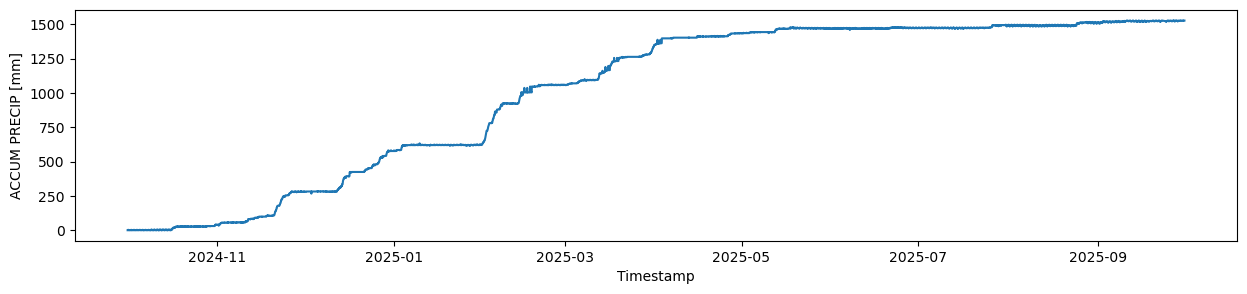

In [163]:
fig = plt.figure(figsize=(15, 3))
plt.plot(df_precip.index, df_precip['PRCP mm'])
plt.xlabel('Timestamp')
plt.ylabel('ACCUM PRECIP [mm]')
print(df_precip.min())

#### manual_observations_WY2025.csv
- percent_snow
- snow_density

In [112]:
# Name
name = "manual_observations_WY2025.csv"

# Path to your data file
filepath = basepath / name

df_man = pd.read_csv(filepath, parse_dates=["Date"])

df_man['Snowpack depth (cm)'] = pd.to_numeric(df_man['Snowpack depth (cm)'], errors='coerce')

df_man = df_man.set_index("Date")


/var/folders/4v/1j346q_s2ps5m3wj8wk2tg880000gn/T/ipykernel_39437/1304808177.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_man = pd.read_csv(filepath, parse_dates=["Date"])


In [113]:
# stuff specific to this application

# convert % to decimal %
df_man["Percent Snow"] = df_man["% of Precip as Snow"]/100

# compute NEW snow density (SWE cm / depth cm)
df_man["Snow Density"] = df_man["Snow Water Equivalent (cm)"]/ df_man["New Snow (cm)"] *1000

# Fill NaNs w/ Zero
df_man["Snow Density"] = df_man["Snow Density"].fillna(0)


In [114]:
print(df_man.columns)

Index(['Air Temp Max (C)', 'Air Temp Min (C)', '24-hour Total Precip (mm)',
       'Season Total Precip (mm)', '% of Precip as Snow',
       '% of Precip as Rain', 'New Snow (cm)', 'Season Total Snow (cm)',
       'Snowpack depth (cm)', 'Snow Water Equivalent (cm)', 'Remarks',
       'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15',
       'Percent Snow', 'Snow Density'],
      dtype='object')


In [115]:
df_man.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2024-10-01 to 2025-09-30
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Air Temp Max (C)            365 non-null    int64  
 1   Air Temp Min (C)            365 non-null    int64  
 2   24-hour Total Precip (mm)   365 non-null    int64  
 3   Season Total Precip (mm)    365 non-null    int64  
 4   % of Precip as Snow         365 non-null    int64  
 5   % of Precip as Rain         365 non-null    int64  
 6   New Snow (cm)               365 non-null    float64
 7   Season Total Snow (cm)      365 non-null    float64
 8   Snowpack depth (cm)         62 non-null     float64
 9   Snow Water Equivalent (cm)  365 non-null    float64
 10  Remarks                     4 non-null      object 
 11  Unnamed: 12                 0 non-null      float64
 12  Unnamed: 13                 0 non-null      float64
 13  Unnamed: 14     

In [116]:
df_man['Snow Density']

Date
2024-10-01    0.0
2024-10-02    0.0
2024-10-03    0.0
2024-10-04    0.0
2024-10-05    0.0
             ... 
2025-09-26    0.0
2025-09-27    0.0
2025-09-28    0.0
2025-09-29    0.0
2025-09-30    0.0
Name: Snow Density, Length: 365, dtype: float64

In [117]:
# upsample to hourly from daily
df_m_1h = df_man[["Percent Snow", "Snow Density"]].resample("1H").ffill() # upsample and fill value for all hours (remove later when compared to precip?)
df_m_1h

/var/folders/4v/1j346q_s2ps5m3wj8wk2tg880000gn/T/ipykernel_39437/3216303143.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_m_1h = df_man[["Percent Snow", "Snow Density"]].resample("1H").ffill() # upsample and fill value for all hours (remove later when compared to precip?)


,Percent Snow,Snow Density
Date,,
2024-10-01 00:00:00,0.0,0.0
2024-10-01 01:00:00,0.0,0.0
2024-10-01 02:00:00,0.0,0.0
2024-10-01 03:00:00,0.0,0.0
2024-10-01 04:00:00,0.0,0.0
...,...,...
2025-09-29 20:00:00,0.0,0.0
2025-09-29 21:00:00,0.0,0.0
2025-09-29 22:00:00,0.0,0.0


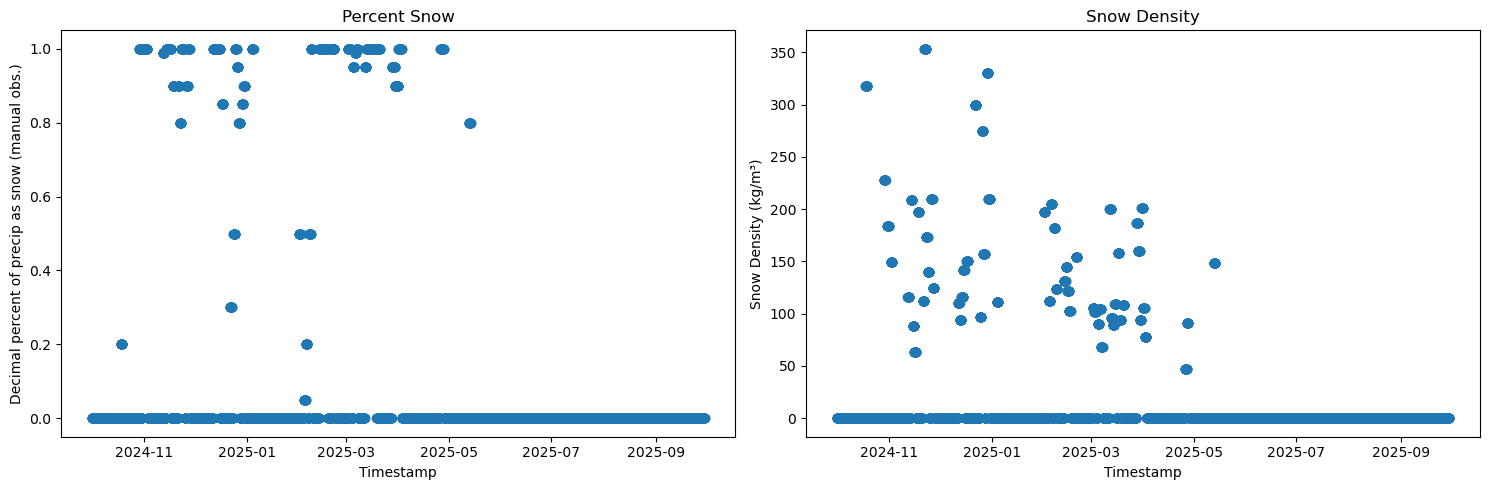

In [162]:
# PLOT IT - hourly % as snow

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Percent Snow
axes[0].scatter(df_m_1h.index, df_m_1h["Percent Snow"])
axes[0].set_xlabel("Timestamp")
axes[0].set_ylabel("Decimal percent of precip as snow (manual obs.)")
axes[0].set_title("Percent Snow")

# Snow Density
axes[1].scatter(df_m_1h.index, df_m_1h["Snow Density"])
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("Snow Density (kg/m³)")
axes[1].set_title("Snow Density")

'''New snow density seems a little high to me, could review data and methods to compute, but all early season and quick look matches 25wy file'''

plt.tight_layout()
plt.show()


#### S2S1_Flux_CSFormat.dat
- vapor pressure

In [119]:
# Name
name = "S2S1_Flux_CSFormat.dat"

# Path to your data file
filepath = basepath / name

# Read the lines manually first
with open(filepath, 'r') as f:
    lines = f.readlines()

# Extract the relevant header rows
column_names = next((line for line in lines if line.startswith('"TIMESTAMP')), None)
units = next((line for line in lines if '"TS"' in line), None)

# Split and strip quotes
column_names = [name.strip('"') for name in column_names.strip().split(',')]
units = [unit.strip('"') for unit in units.strip().split(',')]

# Combine name and unit
combined_headers = [
    f"{name} ({unit})" if unit else name
    for name, unit in zip(column_names, units)
]

# Read the data using pandas, skipping the first 4 rows
df_flux = pd.read_csv(filepath, skiprows=4, names=combined_headers)

# Optionally, parse the timestamp
df_flux['TIMESTAMP (TS)'] = pd.to_datetime(df_flux['TIMESTAMP (TS)'])
df_flux = df_flux.set_index('TIMESTAMP (TS)')

# Format data type
df_flux['e_amb (kPa)'] = pd.to_numeric(df_flux['e_amb (kPa)'], errors='coerce') # convert LW to float

/var/folders/4v/1j346q_s2ps5m3wj8wk2tg880000gn/T/ipykernel_39437/3230243509.py:26: DtypeWarning: Columns (11,13,21,31,37,61,62,66,67,69,76,77,78,79,80,81,86,87) have mixed types. Specify dtype option on import or set low_memory=False.
  df_flux = pd.read_csv(filepath, skiprows=4, names=combined_headers)


In [120]:
# print(df_flux.columns)
df_flux['e_amb (kPa)']

TIMESTAMP (TS)
2023-06-23 15:00:00    0.836056
2023-06-23 15:30:00    0.843662
2023-06-23 16:00:00    0.856875
2023-06-23 16:30:00    0.868627
2023-06-23 17:00:00    0.878894
                         ...   
2025-10-01 22:30:00         NaN
2025-10-01 23:00:00         NaN
2025-10-01 23:30:00         NaN
2025-10-02 00:00:00         NaN
2025-10-02 00:30:00         NaN
Name: e_amb (kPa), Length: 37876, dtype: float64

In [ ]:
# specific to this use case

# downsample to 1 hour from 15 min
df_f_1h = df_flux[['e_amb (kPa)']].resample("1H").mean()

# quick filter for anything >2.5 - clearly an outlier upon first plot
df_f_1h.loc[df_f_1h["e_amb (kPa)"] > 2.5, "e_amb (kPa)"] = np.nan

# quick fill with nearest
df_f_1h["e_amb (kPa)"] = df_f_1h["e_amb (kPa)"].interpolate(method='nearest')

/var/folders/4v/1j346q_s2ps5m3wj8wk2tg880000gn/T/ipykernel_39437/2193440017.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_f_1h = df_flux[['e_amb (kPa)']].resample("1H").mean()


Text(0, 0.5, 'Vapor Pressure (kPa)')

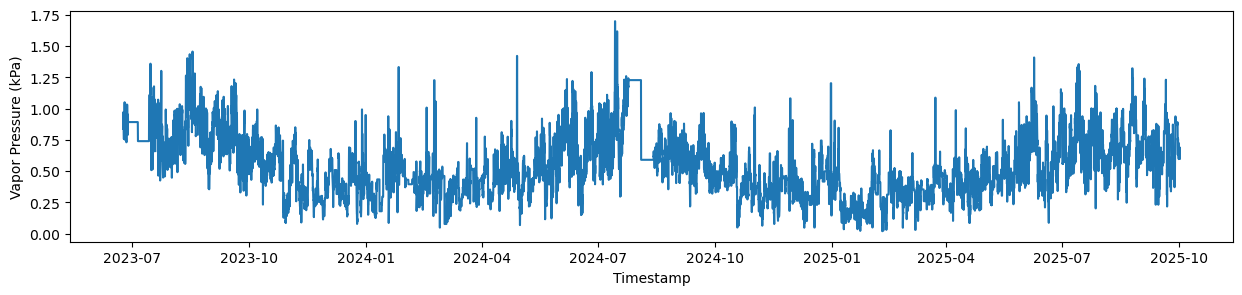

In [160]:
fig = plt.figure(figsize=(15, 3))
plt.plot(df_f_1h.index, df_f_1h['e_amb (kPa)'])
plt.xlabel('Timestamp')
plt.ylabel("Vapor Pressure (kPa)")

#### S2S1_Met_data.dat
- air_temp
- wind_speed
- soil_temp
- net_solar
- thermal (incomming)
- precip_temp - calculated

In [211]:
# Name
name = "S2S1_Met_data.dat"

# Path to your data file
filepath = basepath / name

# Read the lines manually first
with open(filepath, 'r') as f:
    lines = f.readlines()

# Extract the relevant header rows
column_names = next((line for line in lines if line.startswith('"TIMESTAMP')), None)
units = next((line for line in lines if '"TS"' in line), None)

# Split and strip quotes
column_names = [name.strip('"') for name in column_names.strip().split(',')]
units = [unit.strip('"') for unit in units.strip().split(',')]

# Combine name and unit
combined_headers = [
    f"{name} ({unit})" if unit else name
    for name, unit in zip(column_names, units)
]

# Read the data using pandas, skipping the first 4 rows
df_met = pd.read_csv(filepath, skiprows=4, names=combined_headers)

# Optionally, parse the timestamp
df_met['TIMESTAMP (TS)'] = pd.to_datetime(df_met['TIMESTAMP (TS)'])
df_met = df_met.set_index('TIMESTAMP (TS)')

# Format data type
df_met['R_LW_in (W m-2)'] = pd.to_numeric(df_met['R_LW_in (W m-2)'], errors='coerce') # convert LW to float
df_met['R_LW_out (W m-2)'] = pd.to_numeric(df_met['R_LW_in (W m-2)'], errors='coerce') # not using out...
df_met['T_30cm (Deg C)'] = pd.to_numeric(df_met['T_30cm (Deg C)'], errors='coerce')

/var/folders/4v/1j346q_s2ps5m3wj8wk2tg880000gn/T/ipykernel_39437/3488278649.py:26: DtypeWarning: Columns (5,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_met = pd.read_csv(filepath, skiprows=4, names=combined_headers)


In [212]:
print(df_met.columns)

Index(['RECORD (RN)', 'BP_CS100 (mbar)', 'T_probe (deg C)',
       'T_DP_Probe (deg C)', 'RH_probe (%)', 'WS_05108_mean (m/s)',
       'WS_05108_rslt (m/s)', 'WD_05108_mean (degrees)',
       'WD_05108_StdDev (degrees)', 'WS_05108_Max (m/s)', 'R_SW_in (W m-2)',
       'R_SW_out (W m-2)', 'R_LW_in (W m-2)', 'R_LW_out (W m-2)', 'albedo (%)',
       'METAR', 'VWC_5cm (m^3/m^3)', 'Ka_5cm (unitless)', 'T_5cm (Deg C)',
       'BulkEC_5cm (dS/m)', 'VWC_10cm (m^3/m^3)', 'Ka_10cm (unitless)',
       'T_10cm (Deg C)', 'BulkEC_10cm (dS/m)', 'VWC_20cm (m^3/m^3)',
       'Ka_20cm (unitless)', 'T_20cm (Deg C)', 'BulkEC_20cm (dS/m)',
       'VWC_30cm (m^3/m^3)', 'Ka_30cm (unitless)', 'T_30cm (Deg C)',
       'BulkEC_30cm (dS/m)', 'VWC_40cm (m^3/m^3)', 'Ka_40cm (unitless)',
       'T_40cm (Deg C)', 'BulkEC_40cm (dS/m)', 'VWC_50cm (m^3/m^3)',
       'Ka_50cm (unitless)', 'T_50cm (Deg C)', 'BulkEC_50cm (dS/m)',
       'VWC_60cm (m^3/m^3)', 'Ka_60cm (unitless)', 'T_60cm (Deg C)',
       'BulkEC_60cm (dS/

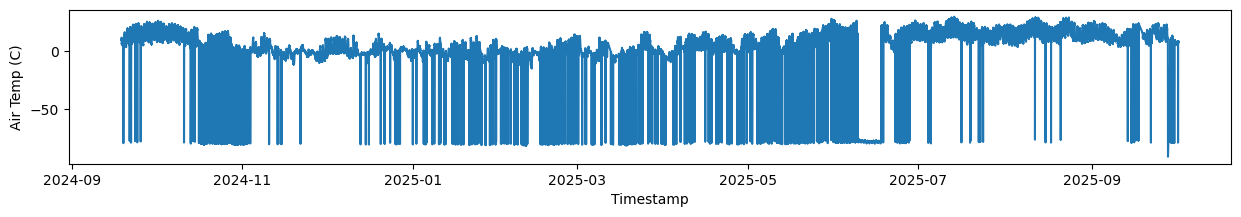

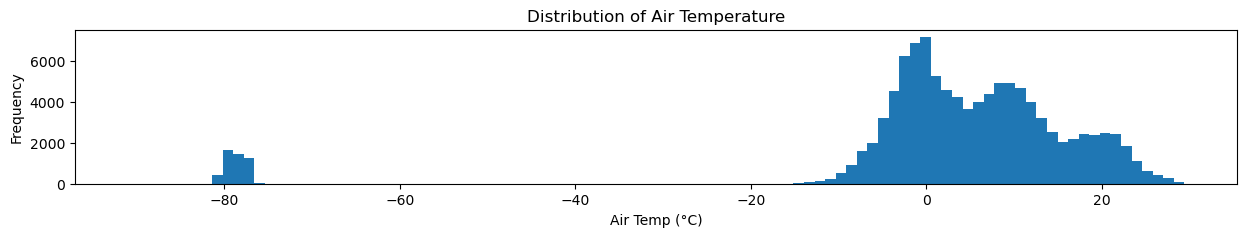

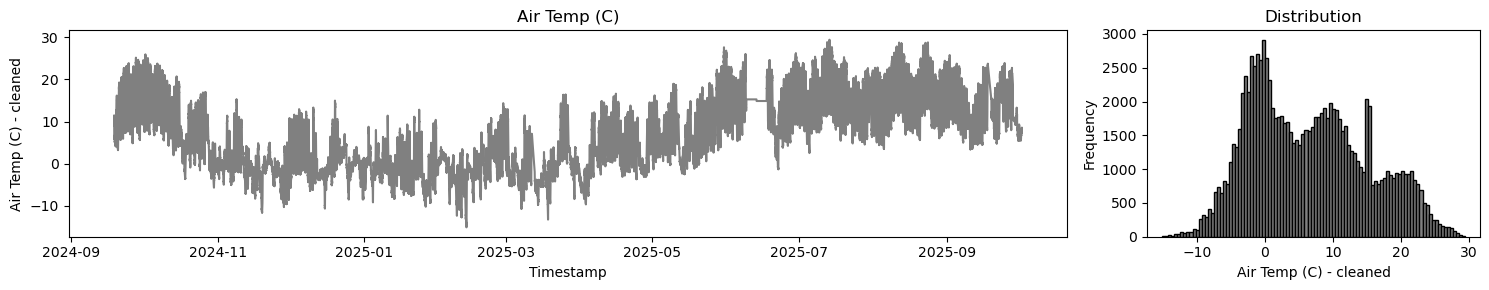

In [213]:
# AIR TEMP
fig = plt.figure(figsize=(15, 2))
plt.plot(df_met.index, df_met['T_probe (deg C)'])
plt.xlabel('Timestamp')
plt.ylabel("Air Temp (C)")

fig = plt.figure(figsize=(15, 2))
plt.hist(df_met['T_probe (deg C)'], bins=100) 
plt.xlabel('Air Temp (°C)')
plt.ylabel('Frequency')
plt.title('Distribution of Air Temperature')
plt.show()

# remove all air temps <-20 C
df_met.loc[df_met['T_probe (deg C)'] < -20, 'T_probe (deg C)'] = np.nan

# interpolate to the nearest
df_met['T_probe (deg C)'] = df_met['T_probe (deg C)'].interpolate(method='nearest')

# plot again, with histogram
fig = plt.figure(figsize=(15, 3))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1])  # 3/4 : 1/4 width ratio

# --- First subplot (time series) ---
ax1 = plt.subplot(gs[0])
ax1.plot(df_met.index, df_met['T_probe (deg C)'], color='gray')
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Air Temp (C) - cleaned')
ax1.set_title('Air Temp (C)')

# --- Second subplot (histogram) ---
ax2 = plt.subplot(gs[1])
ax2.hist(df_met['T_probe (deg C)'], bins=100, color='gray', edgecolor='black')
ax2.set_xlabel('Air Temp (C) - cleaned')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution')
plt.tight_layout()
plt.show()

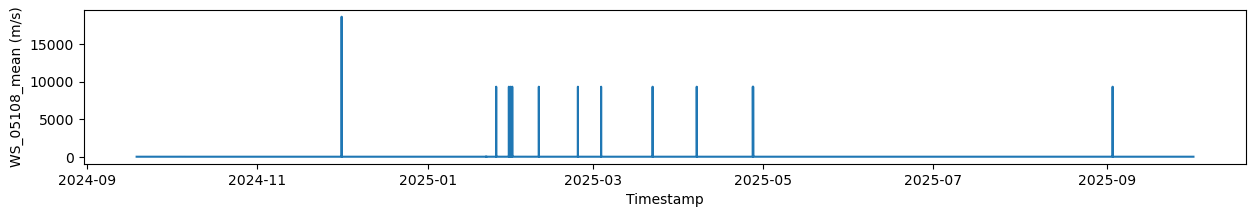

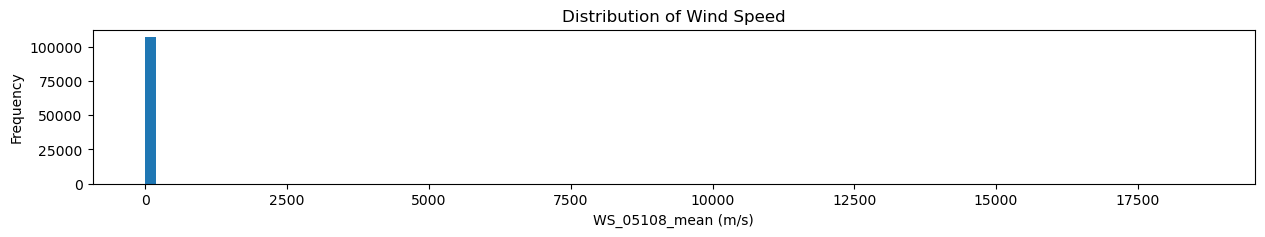

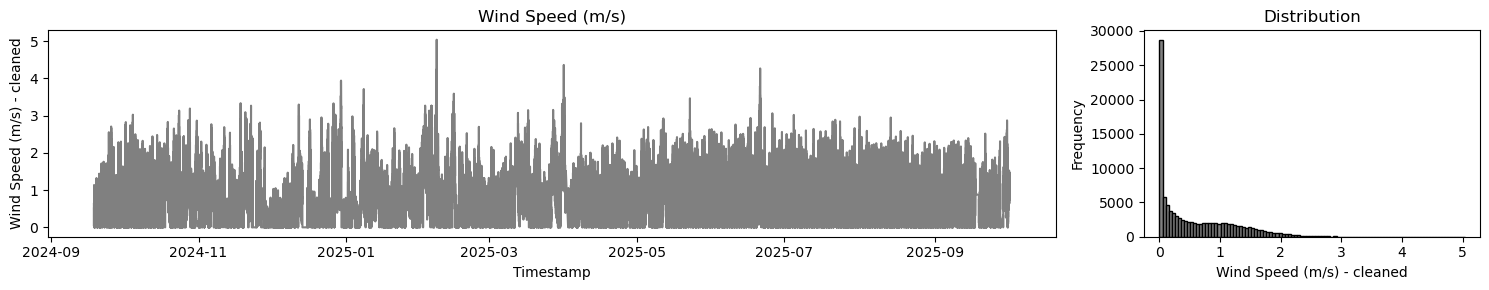

In [ ]:
# WIND SPEED
fig = plt.figure(figsize=(15, 2))
plt.plot(df_met.index, df_met['WS_05108_mean (m/s)'])
plt.xlabel('Timestamp')
plt.ylabel("WS_05108_mean (m/s)")

# Replace inf with Nan
df_met['WS_05108_mean (m/s)'] = df_met['WS_05108_mean (m/s)'].replace([np.inf, -np.inf], np.nan)

fig = plt.figure(figsize=(15, 2))
plt.hist(df_met['WS_05108_mean (m/s)'], bins=100)
plt.xlabel("WS_05108_mean (m/s)")
plt.ylabel('Frequency')
plt.title('Distribution of Wind Speed')
plt.show()

# Remove values >5000
df_met.loc[df_met['WS_05108_mean (m/s)'] >5000, 'WS_05108_mean (m/s)'] = np.nan

# interpolate to the nearest
df_met['WS_05108_mean (m/s)'] = df_met['WS_05108_mean (m/s)'].interpolate(method='nearest')

# plot again, with histogram
fig = plt.figure(figsize=(15, 3))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1])  # 3/4 : 1/4 width ratio

# --- First subplot (time series) ---
ax1 = plt.subplot(gs[0])
ax1.plot(df_met.index, df_met['WS_05108_mean (m/s)'], color='gray')
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Wind Speed (m/s) - cleaned')
ax1.set_title('Wind Speed (m/s)')

# --- Second subplot (histogram) ---
ax2 = plt.subplot(gs[1])
ax2.hist(df_met['WS_05108_mean (m/s)'], bins=100, color='gray', edgecolor='black')
ax2.set_xlabel('Wind Speed (m/s) - cleaned')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution')
plt.tight_layout()
plt.show()



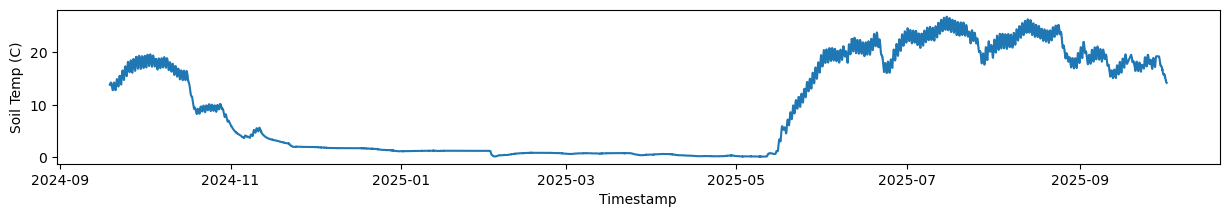

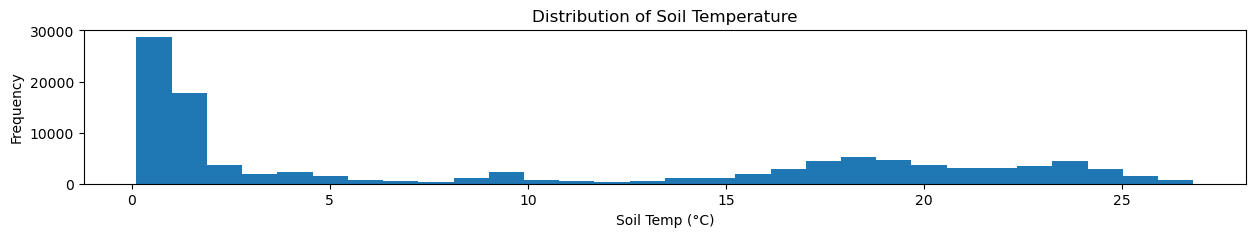

In [ ]:
# SOIL TEMP
fig = plt.figure(figsize=(15, 2))
plt.plot(df_met.index, df_met['T_30cm (Deg C)'])
plt.xlabel('Timestamp')
plt.ylabel("Soil Temp (C)")

fig = plt.figure(figsize=(15, 2))
plt.hist(df_met['T_30cm (Deg C)'], bins=30) 
plt.xlabel('Soil Temp (°C)')
plt.ylabel('Frequency')
plt.title('Distribution of Soil Temperature')
plt.show()

# soil looks good!

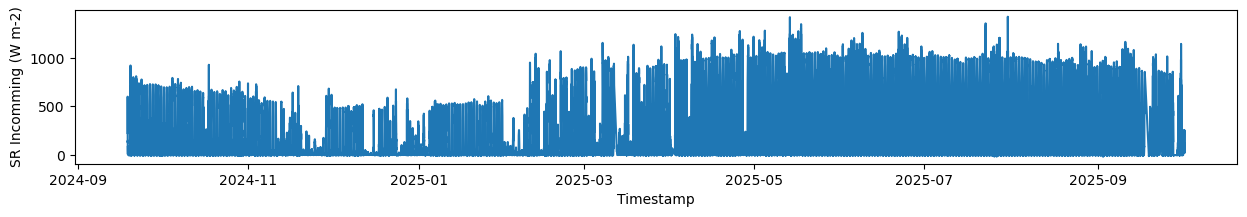

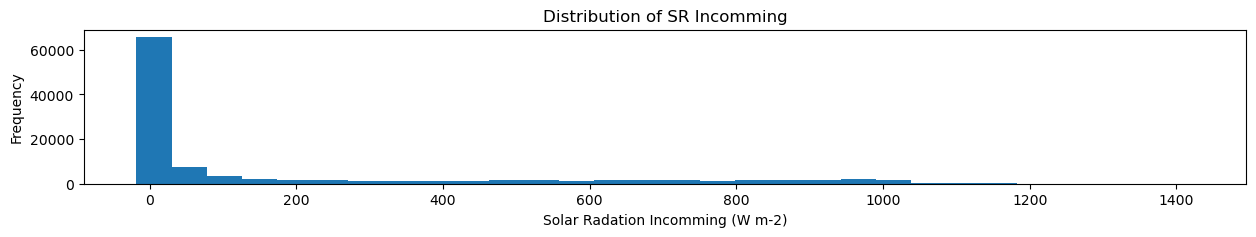

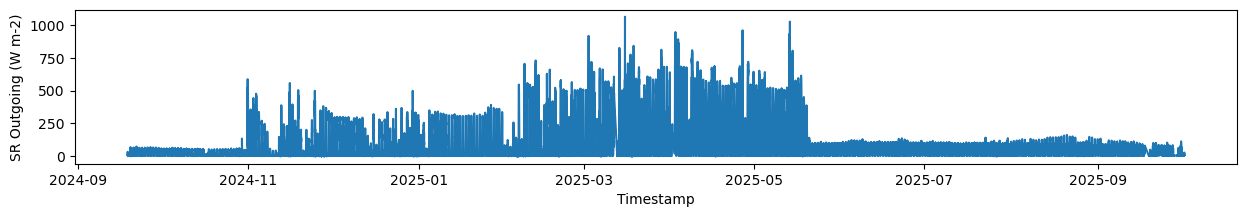

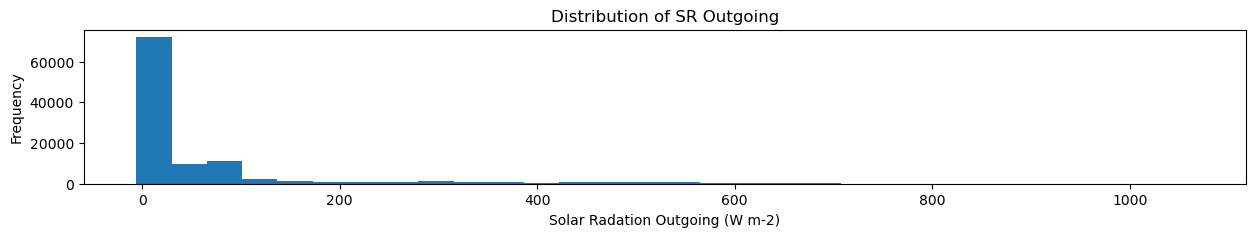

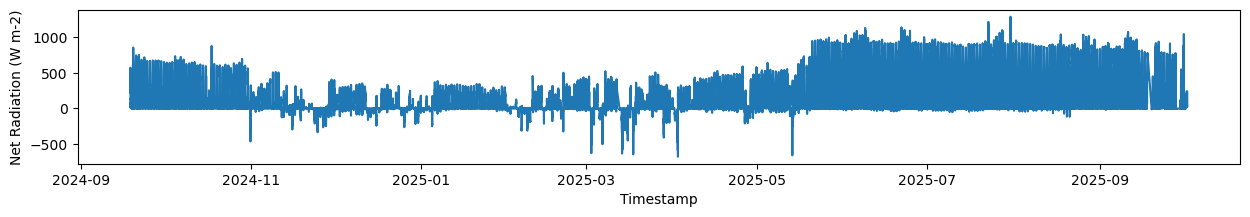

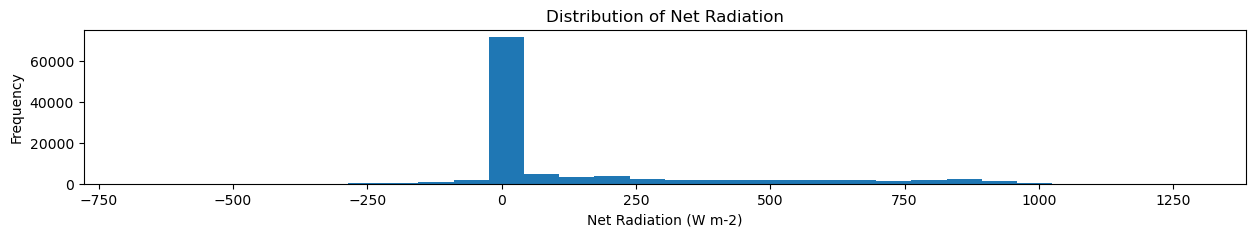

In [232]:
# Solar Radiation (incomming)
fig = plt.figure(figsize=(15, 2))
plt.plot(df_met.index, df_met['R_SW_in (W m-2)'])
plt.xlabel('Timestamp')
plt.ylabel("SR Incomming (W m-2)")

fig = plt.figure(figsize=(15, 2))
plt.hist(df_met['R_SW_in (W m-2)'], bins=30) 
plt.xlabel('Solar Radation Incomming (W m-2)')
plt.ylabel('Frequency')
plt.title('Distribution of SR Incomming')
plt.show()

# Solar Radiation (outgoing)
fig = plt.figure(figsize=(15, 2))
plt.plot(df_met.index, df_met['R_SW_out (W m-2)'])
plt.xlabel('Timestamp')
plt.ylabel("SR Outgoing (W m-2)")

fig = plt.figure(figsize=(15, 2))
plt.hist(df_met['R_SW_out (W m-2)'], bins=30) 
plt.xlabel('Solar Radation Outgoing (W m-2)')
plt.ylabel('Frequency')
plt.title('Distribution of SR Outgoing')
plt.show()

# Solar Radiation (net)
fig = plt.figure(figsize=(15, 2))
plt.plot(df_met.index, df_met['R_SW_in (W m-2)'] - df_met['R_SW_out (W m-2)'])
plt.xlabel('Timestamp')
plt.ylabel("Net Radiation (W m-2)")

fig = plt.figure(figsize=(15, 2))
plt.hist(df_met['R_SW_in (W m-2)'] - df_met['R_SW_out (W m-2)'], bins=30) 
plt.xlabel('Net Radiation (W m-2)')
plt.ylabel('Frequency')
plt.title('Distribution of Net Radiation')
plt.show()

# compute Net Radation
df_met["Net_solar (W m-2)"] = df_met["R_SW_in (W m-2)"] - df_met["R_SW_out (W m-2)"]


# initial values all look resonable, probably needs a closer look at some point




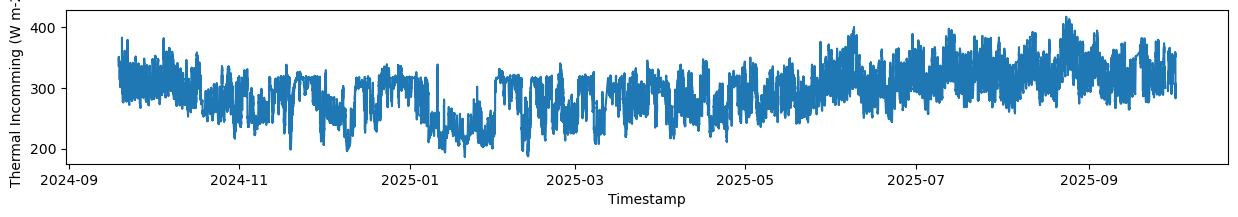

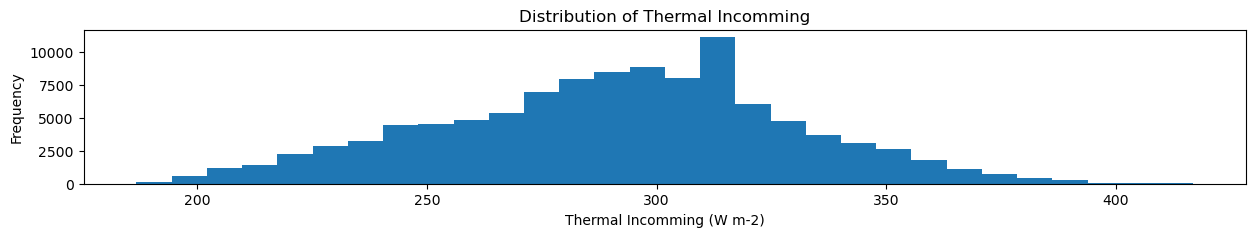

In [233]:
# Thermal Radiation (incoming) - longwave 
fig = plt.figure(figsize=(15, 2))
plt.plot(df_met.index, df_met['R_LW_in (W m-2)'])
plt.xlabel('Timestamp')
plt.ylabel("Thermal Incomming (W m-2)")

fig = plt.figure(figsize=(15, 2))
plt.hist(df_met['R_LW_in (W m-2)'], bins=30) 
plt.xlabel('Thermal Incomming (W m-2)')
plt.ylabel('Frequency')
plt.title('Distribution of Thermal Incomming')
plt.show()

In [241]:
# WET BULB TEMPERATURE - variables 

# Pressure
fig = plt.figure(figsize=(15, 2))
plt.plot(df_met.index, df_met['BP_CS100 (mbar)'])
plt.xlabel('Timestamp')
plt.ylabel("Barometric Pressure (mbar)")

# Air Temp - handled above and plotted again
fig = plt.figure(figsize=(15, 2))
plt.plot(df_met.index, df_met['T_probe (deg C)'])
plt.xlabel('Timestamp')
plt.ylabel("Air Temp (C)")

# Dew Point 
fig = plt.figure(figsize=(15, 2))
plt.plot(df_met.index, df_met['T_DP_Probe (deg C)'])
plt.xlabel('Timestamp')
plt.ylabel("Dew Point (C)")


df_met['Precip_Temp (deg C)'] = wet_bulb_temperature(
    df_met['BP_CS100 (mbar)'].values * units.mbar,
    df_met['T_probe (deg C)'].values * units.degC,
    df_met['T_DP_Probe (deg C)'].values * units.degC
).to('degC')

fig = plt.figure(figsize=(15, 2))
plt.plot(df_met.index, df_met['Precip_Temp (deg C)'], color='gray')
plt.xlabel('Timestamp')
plt.ylabel("Wet Bulb Temp (C)")

KeyError: 'BP_CS100 (mbar)'

<Figure size 1500x200 with 0 Axes>

In [237]:
df_met.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 107230 entries, 2024-09-18 19:25:00 to 2025-10-02 00:55:00
Data columns (total 54 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   RECORD (RN)                107230 non-null  int64  
 1   BP_CS100 (mbar)            107230 non-null  float64
 2   T_probe (deg C)            107230 non-null  float64
 3   T_DP_Probe (deg C)         107230 non-null  float64
 4   RH_probe (%)               107230 non-null  object 
 5   WS_05108_mean (m/s)        107230 non-null  float64
 6   WS_05108_rslt (m/s)        107230 non-null  float64
 7   WD_05108_mean (degrees)    107230 non-null  float64
 8   WD_05108_StdDev (degrees)  107230 non-null  float64
 9   WS_05108_Max (m/s)         107230 non-null  float64
 10  R_SW_in (W m-2)            107230 non-null  float64
 11  R_SW_out (W m-2)           107230 non-null  float64
 12  R_LW_in (W m-2)            107180 non-null  float64


In [ ]:
# columns to keep
df_met_filt = df_met[["T_probe (deg C)", "WS_05108_mean (m/s)", "T_30cm (Deg C)", "Net_solar (W m-2)", "R_LW_in (W m-2)", "Precip_Temp (deg C)"]]

df_met_filt.info()

# downsample to hourly from 5 min
df_met_1h = df_met_filt.resample("1H").mean()

df_met_1h.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 107230 entries, 2024-09-18 19:25:00 to 2025-10-02 00:55:00
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   T_probe (deg C)      107230 non-null  float64
 1   WS_05108_mean (m/s)  107230 non-null  float64
 2   T_30cm (Deg C)       107209 non-null  float64
 3   Net_solar (W m-2)    107230 non-null  float64
 4   R_LW_in (W m-2)      107180 non-null  float64
 5   Precip_Temp (deg C)  107230 non-null  float64
dtypes: float64(6)
memory usage: 5.7 MB


/var/folders/4v/1j346q_s2ps5m3wj8wk2tg880000gn/T/ipykernel_39437/2346448165.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_met_1h = df_met.resample("1H").mean()


,T_probe (deg C),WS_05108_mean (m/s),T_30cm (Deg C),Net_solar (W m-2),R_LW_in (W m-2),Precip_Temp (deg C)
count,8945.000000,8945.000000,8945.000000,8945.000000,8942.000000,8945.000000
mean,6.412648,0.606861,9.576748,122.591265,291.007490,2.254635
std,8.583155,0.597873,9.306520,242.030453,37.824080,5.725916
min,-14.866082,0.000000,0.125000,-406.639122,187.541225,-15.317301
25%,-0.708433,0.072101,0.874000,-4.643616,265.903487,-2.187564
50%,5.671298,0.401923,4.155000,-0.440563,293.581462,2.155250
75%,12.646278,1.052588,18.867500,139.419483,316.151742,6.977560
max,29.004958,3.298819,26.780000,998.964387,406.988658,16.650779


#### Dataframes to merge:
df_p_1h

df_precip --> precip (PST)
df_m_1h --> percent_snow, snow_density (PST)
df_f_1h --> vapor_pressure (UTC)
df_met_1h --> air_temp, wind_speed, soil_temp_30cm, net_radiation, thermal_radiation, precip_temp (UTC)

In [252]:
# merge timezones - all to PST
pst = pytz.FixedOffset(-8*60)  # -8 hours in minutes

# 1. df_precip --> convert to all PST
df_precip.index = df_precip.index.tz_localize(None)
df_precip.index = df_precip.index.tz_localize(pst)
df_precip.index = df_precip.index.tz_localize(None)

# # 2. df_m_1h --> make TZ aware
df_m_1h.index = df_m_1h.index.tz_localize(None)
df_m_1h.index = df_m_1h.index.tz_localize(pst)
df_m_1h.index = df_m_1h.index.tz_localize(None)

# # 3. df_f_1h
df_f_1h.index = df_f_1h.index.tz_localize(None)
df_f_1h.index = df_f_1h.index.tz_localize(pst)
df_f_1h.index = df_f_1h.index.tz_localize(None)

# # 4. df_met_1h
df_met_1h.index = df_met_1h.index.tz_localize(None)
df_met_1h.index = df_met_1h.index.tz_localize(pst)
df_met_1h.index = df_met_1h.index.tz_localize(None)


In [ ]:
# Filter start/end date (could move this higher up... start/end at top of script)
df_precip = df_precip.loc[start_date:end_date]
df_m_1h   = df_m_1h.loc[start_date:end_date]
df_f_1h   = df_f_1h.loc[start_date:end_date]
df_met_1h = df_met_1h.loc[start_date:end_date]

In [256]:
print(df_precip.head(3))
print(df_m_1h.head(3))
print(df_f_1h.head(3))
print(df_met_1h.head(3))

                     PREC.I-1 (in)   PRCP mm
Timestamp                                   
2024-10-01 00:00:00             0.0      0.0
2024-10-01 01:00:00             0.0      0.0
2024-10-01 02:00:00             0.0      0.0
                     Percent Snow  Snow Density
Date                                           
2024-10-01 00:00:00           0.0           0.0
2024-10-01 01:00:00           0.0           0.0
2024-10-01 02:00:00           0.0           0.0
                     e_amb (kPa)
TIMESTAMP (TS)                  
2024-10-01 00:00:00     0.491465
2024-10-01 01:00:00     0.504545
2024-10-01 02:00:00     0.503879
                     T_probe (deg C)  WS_05108_mean (m/s)  T_30cm (Deg C)  \
TIMESTAMP (TS)                                                              
2024-10-01 00:00:00        23.238228             0.496653       17.780833   
2024-10-01 01:00:00        20.517864             0.187656       18.165000   
2024-10-01 02:00:00        16.266407             0.026054     

In [271]:
# merge into single DataFrame
df = pd.concat([df_precip, df_m_1h, df_f_1h, df_met_1h], axis=1)
df.describe()
# df.columns

,PREC.I-1 (in),PRCP mm,Percent Snow,Snow Density,e_amb (kPa),T_probe (deg C),WS_05108_mean (m/s),T_30cm (Deg C),Net_solar (W m-2),R_LW_in (W m-2),Precip_Temp (deg C)
count,8627.000000,8698.000000,8737.000000,8737.000000,8737.000000,8604.000000,8604.000000,8604.000000,8604.000000,8601.000000,8604.000000
mean,39.731923,1005.761035,0.155147,23.817458,0.473627,6.185462,0.610683,9.315967,121.694179,290.261376,2.103121
std,21.687050,553.837165,0.351048,60.856420,0.228527,8.590691,0.601421,9.387964,242.328823,38.041645,5.768446
min,0.000000,0.000000,0.000000,0.000000,0.019437,-14.866082,0.000000,0.125000,-406.639122,187.541225,-15.317301
25%,22.700000,576.580000,0.000000,0.000000,0.313010,-0.874852,0.071307,0.835000,-4.637876,264.209275,-2.340941
50%,52.400000,1316.990000,0.000000,0.000000,0.442481,5.062193,0.404121,3.348333,-0.443294,293.024050,1.757308
75%,58.000000,1473.200000,0.000000,0.000000,0.600146,12.432142,1.063891,19.029583,137.339366,316.014208,6.864102
max,60.200000,1529.080000,1.000000,353.333333,1.409317,29.004958,3.298819,26.780000,998.964387,406.988658,16.650779


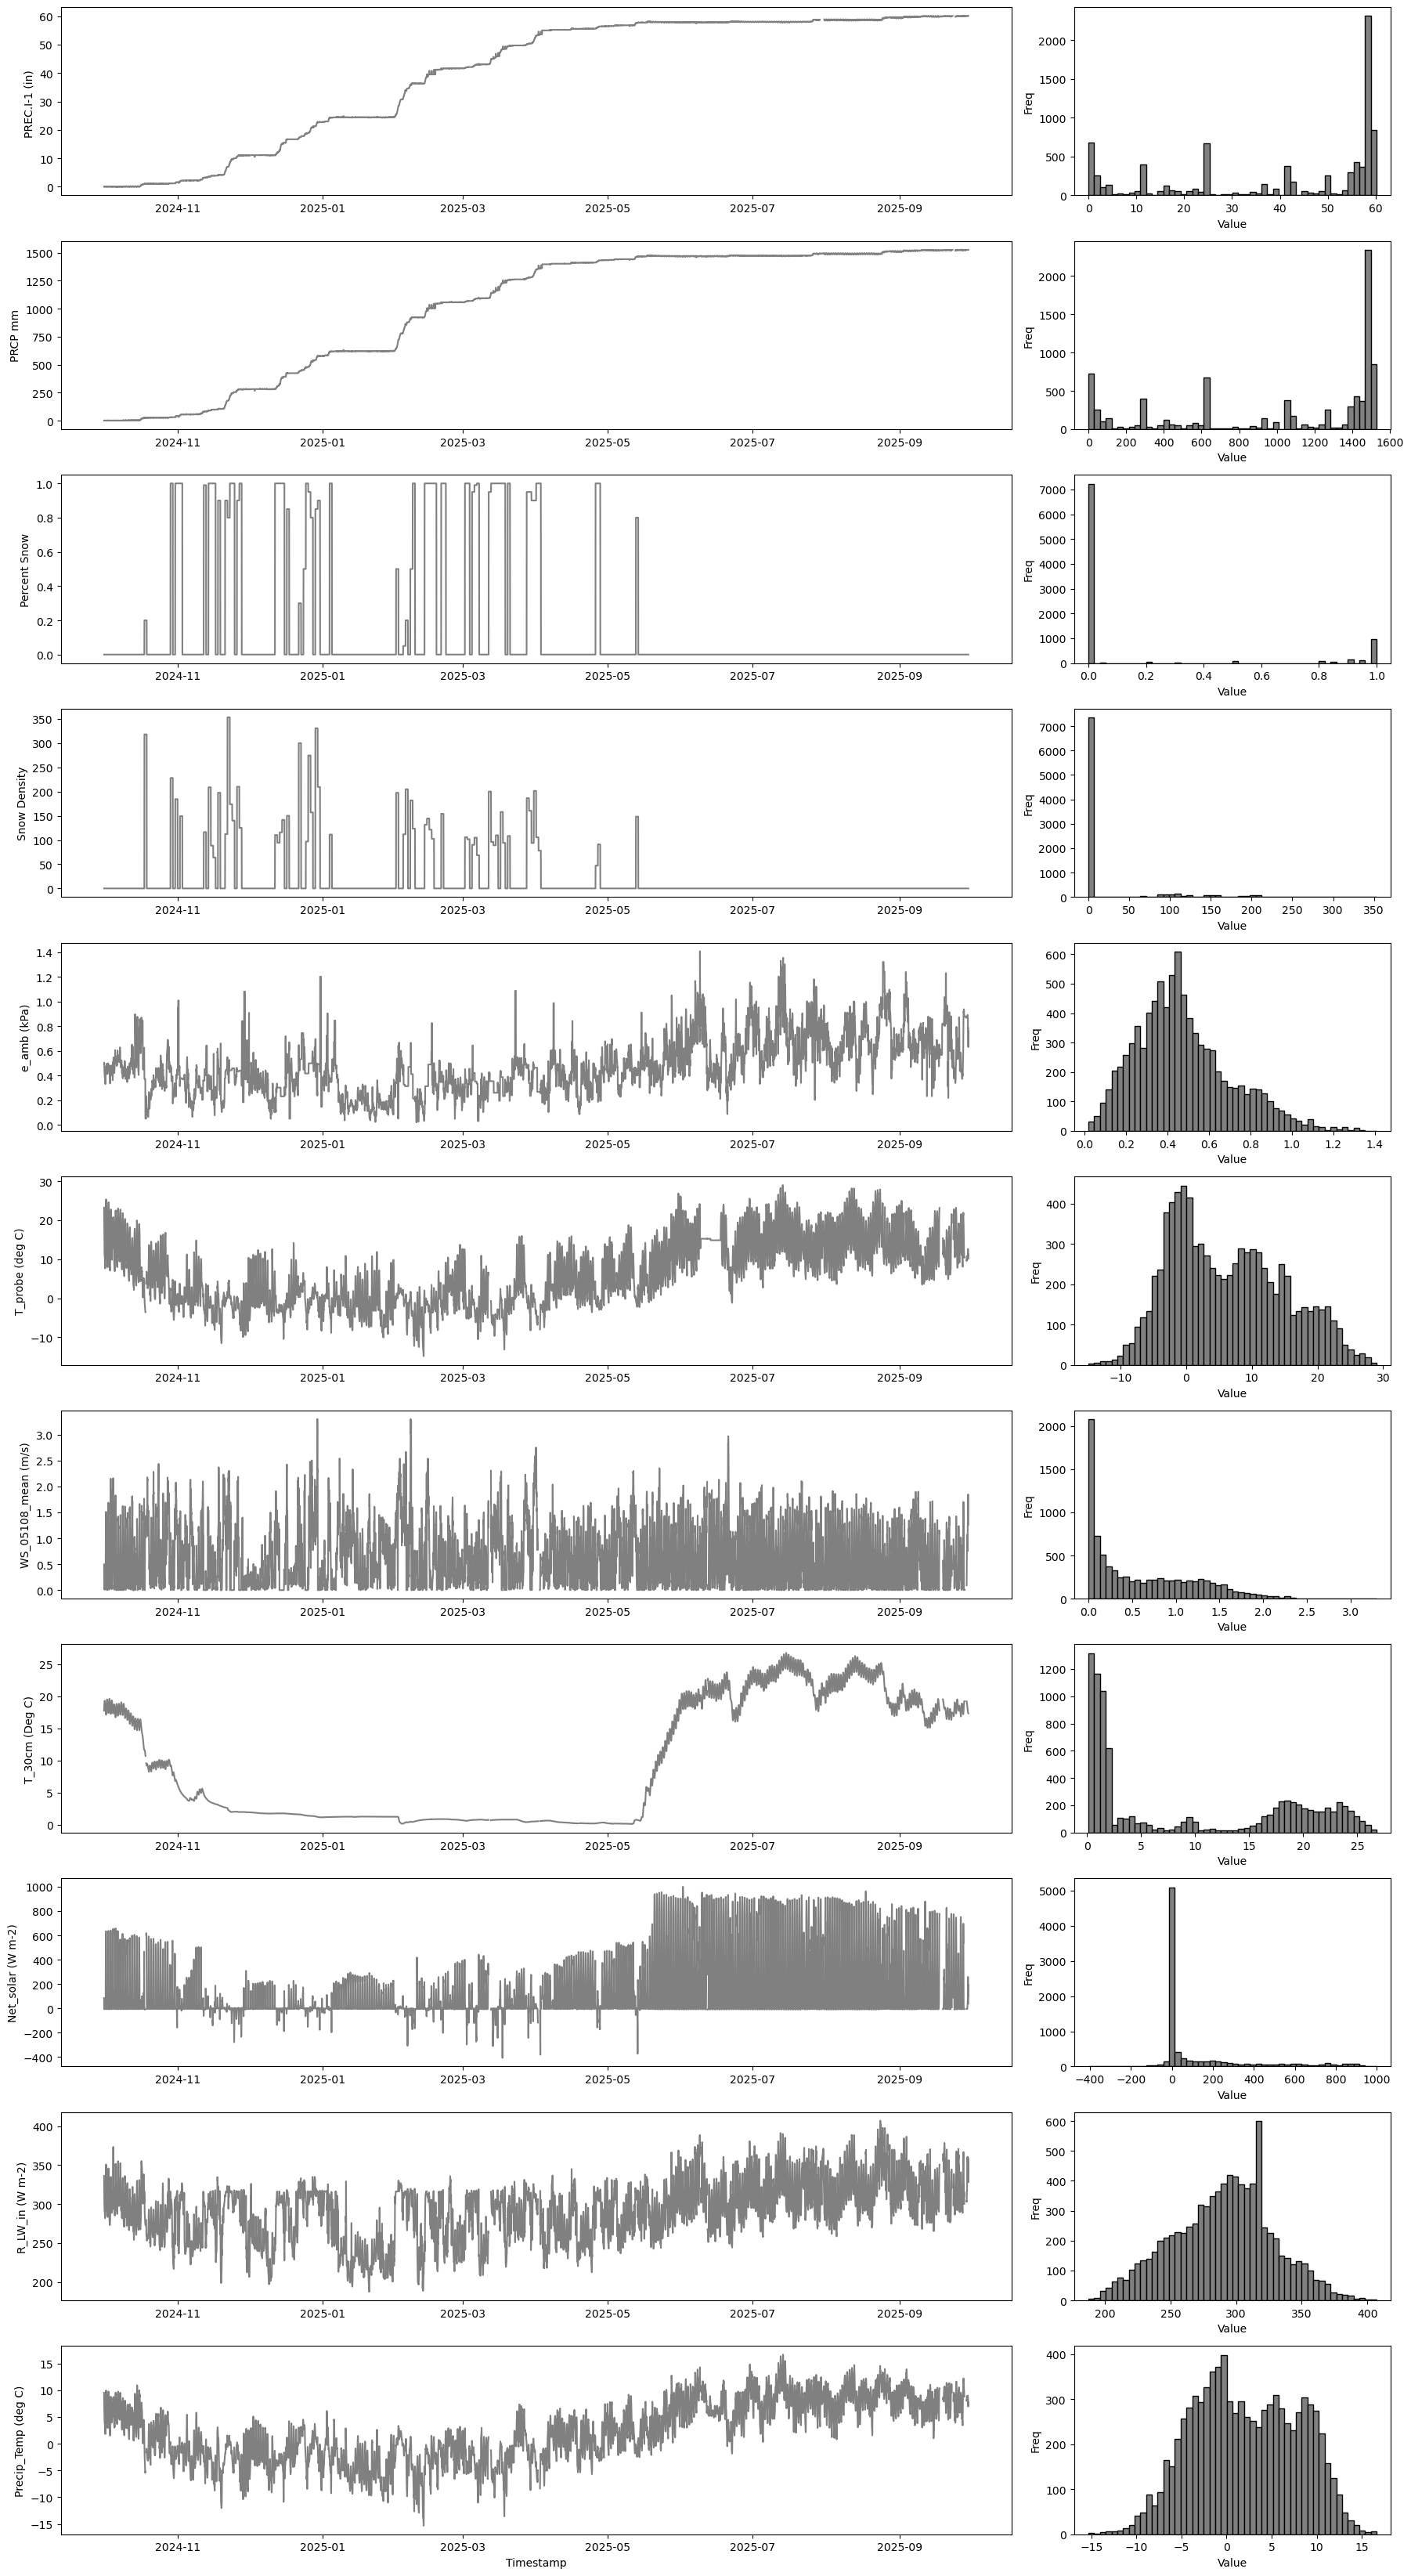

In [ ]:
# Let's plot it all


# List of variables to plot
cols_to_plot = [
    'PREC.I-1 (in) ', 'PRCP mm', 'Percent Snow', 'Snow Density',
    'e_amb (kPa)', 'T_probe (deg C)', 'WS_05108_mean (m/s)',
    'T_30cm (Deg C)', 'Net_solar (W m-2)', 'R_LW_in (W m-2)',
    'Precip_Temp (deg C)'
]

n_vars = len(cols_to_plot)
fig = plt.figure(figsize=(18, 3 * n_vars))  # 3 inches per variable for vertical spacing

for i, col in enumerate(cols_to_plot):
    # GridSpec layout for each variable row: 1 row, 2 columns
    gs = gridspec.GridSpec(n_vars, 2, width_ratios=[3, 1], height_ratios=[1]*n_vars)
    
    # --- Line plot (3/4 width) ---
    ax_line = plt.subplot(gs[i, 0])
    ax_line.plot(df.index, df[col], color='grey')
    ax_line.set_ylabel(col)
    if i == n_vars - 1:
        ax_line.set_xlabel('Timestamp')
    
    # --- Histogram (1/4 width) ---
    ax_hist = plt.subplot(gs[i, 1])
    data = df[col].dropna()
    ax_hist.hist(data, bins=50, color='grey', edgecolor='black')
    ax_hist.set_xlabel('Value')
    ax_hist.set_ylabel('Freq')
    
plt.tight_layout()
plt.show()


In [ ]:
# Final clean up
df.index.name = 'Timestamp' 
df = df.reset_index() 



# rename columns
df = df.drop(columns=['PREC.I-1 (in) '], errors='ignore')  # errors='ignore' avoids issues if already gone

# Define a mapping of old names → new names
rename_dict = {
    'Timestamp': 'datetime',
    'T_probe (deg C)': 'air_temp',
    'Net_solar (W m-2)': 'net_solar',
    'Percent Snow': 'percent_snow',
    'PRCP mm': 'precip',
    'Precip_Temp (deg C)': 'precip_temp',
    'Snow Density': 'snow_density',
    'R_LW_in (W m-2)': 'thermal',
    'e_amb (kPa)': 'vapor_pressure',
    'WS_05108_mean (m/s)': 'wind_speed',  
    'T_30cm (Deg C)': 'soil_temp'
}

# Rename columns
df = df.rename(columns=rename_dict)

# Check
print(df.columns)

# datetime	air_temp	net_solar	percent_snow	precip	precip_temp	snow_density	thermal	vapor_pressure	wind_direction	wind_speed	soil_temp

# 'Timestamp', 'T_probe (deg C)', 'Net_solar (W m-2)', 'Percent Snow', 'PRCP mm', 'Precip_Temp (deg C)', 'Snow Density', 'R_LW_in (W m-2)', 'e_amb (kPa)', 'WS_05108_mean (m/s)', 'T_30cm (Deg C)'

#  'PREC.I-1 (in) ', 'PRCP mm', 'Percent Snow', 'Snow Density',
#     'e_amb (kPa)', 'T_probe (deg C)', 'WS_05108_mean (m/s)',
#     'T_30cm (Deg C)', 'Net_solar (W m-2)', 'R_LW_in (W m-2)',
#     'Precip_Temp (deg C)'
 




Index(['datetime', 'precip', 'percent_snow', 'snow_density', 'vapor_pressure',
       'air_temp', 'wind_speed', 'soil_temp', 'net_solar', 'thermal',
       'precip_temp'],
      dtype='object')


In [273]:
# Let's save the merged dataframe with all forcing data we need to run iSnobal
out_path = Path('/Users/meganmason/Documents/projects/cold-content/modeling/iSnobal/csl-wy25')
df.to_csv(out_path.joinpath('inputs_csl_2025.csv'))

In [274]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8737 entries, 0 to 8736
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   datetime        8737 non-null   datetime64[ns]
 1   precip          8698 non-null   float64       
 2   percent_snow    8737 non-null   float64       
 3   snow_density    8737 non-null   float64       
 4   vapor_pressure  8737 non-null   float64       
 5   air_temp        8604 non-null   float64       
 6   wind_speed      8604 non-null   float64       
 7   soil_temp       8604 non-null   float64       
 8   net_solar       8604 non-null   float64       
 9   thermal         8601 non-null   float64       
 10  precip_temp     8604 non-null   float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 751.0 KB
